# Code Vulnerability Security DPO

**Dataset:** [`CyberNative/Code_Vulnerability_Security_DPO`](https://huggingface.co/datasets/CyberNative/Code_Vulnerability_Security_DPO)  
**Datos:** `data/raw/top10_security/03_CyberNative__Code_Vulnerability_Security_DPO/`  
**Notebook:** [`eda.ipynb`](eda.ipynb)

## Qué es
Este tercer dataset cambia completamente de enfoque respecto a los anteriores: ya no trata de saltarse filtros de texto (jailbreaks), sino de enseñar a los modelos a programar sin vulnerabilidades de seguridad

Es un conjunto de **4.656 pares de entrenamiento DPO sintéticos** generados con el modelo `deepseek-coder-33b`. Su propósito es alinear modelos de lenguaje para que generen código seguro (`chosen`) en lugar de código con fallos de seguridad (`rejected`).

---

## Estructura de Datos

* **Archivo principal:** `secure_programming_dpo.json` (~6.55 MB, formato JSON Lines).
* **Columnas:**
  * **`lang`**: Lenguaje de programación (cubre 11 lenguajes equilibrados con ~423 ejemplos cada uno: Python, C++, Java, JS, C#, PHP, Go, Ruby, Swift, Kotlin y Fortran).
  * **`vulnerability`**: Explicación de la debilidad de seguridad abordada (SQLi, XSS, Buffer Overflow, etc.).
  * **`system`**: Instrucción de sistema para condicionar al modelo.
  * **`question`**: Tarea o petición de desarrollo del usuario.
  * **`chosen`**: Implementación segura recomendada.
  * **`rejected`**: Implementación vulnerable con el fallo de seguridad.

---

## Aspectos Clave a Evaluar en el EDA

1. **Sesgo de longitud (`chosen` vs `rejected`):** Es común que los modelos generadores hagan la respuesta segura más larga porque incluye validaciones y comentarios. Si `chosen` es sistemáticamente mucho más largo que `rejected`, el modelo podría aprender a preferir respuestas largas por su tamaño y no por su seguridad.
2. **Cobertura por lenguaje:** Verificar si los 11 lenguajes están verdaderamente balanceados.
3. **Calidad sintética:** Al ser generado por otra IA (`deepseek-coder-33b`), evaluar si hay duplicados o patrones repetitivos en las preguntas.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("03")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\03_CyberNative__Code_Vulnerability_Security_DPO
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\03_code_vulnerability_dpo  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.json,1,6.868
.md,1,0.004
,1,0.002


,archivo,ext,size_mb
0,secure_programming_dpo.json,.json,6.868
1,README.md,.md,0.004
2,.gitattributes,,0.002


## 2. Cargar

In [3]:
PATH = ctx.data_dir / "secure_programming_dpo.json"
df = load_table(PATH)
print(df.shape)
display(df.head(3))
display(profile_df(df))

(4656, 6)


,lang,vulnerability,system,question,chosen,rejected
0,c++,Improper memory management in C++ can lead to buffer overflow vulnerabilities.,,Write a c++ code that defines a function named 'copyString' which takes two character pointers as arguments. The fir...,"```c++\n#include <cstring>\n\nvoid copyString(char* dest, const char* src) {\n while ((*dest++ = *src++) != '\0')...","```c++\n#include <cstring>\n\nvoid copyString(char* dest, const char* src) {\n while (*src != '\0') {\n *d..."
1,python,Python's built-in function `eval()` can lead to arbitrary code execution if used improperly.,,Write a python code that takes user input as Python code and executes it using the built-in `eval()` function. The e...,"```python\nimport ast\n\nclass RestrictedPython(ast.NodeTransformer):\n """"""\n AST NodeTransformer that restric...",```python\nimport os\n\ndef evaluate_input(user_input):\n # This function uses eval() to evaluate the user input ...
2,java,Improper null check on database results can lead to NullPointerException.,,"Write a java code that connects to a MySQL database, executes a SELECT query on the 'users' table where the 'usernam...",```java\nimport java.sql.*;\n\npublic class Main {\n public static void main(String[] args) {\n Connection...,```java\nimport java.sql.*;\n\npublic class Main {\n public static void main(String[] args) {\n Connection...


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
lang,object,0,0.0,0,11,4.7,4.0,10
vulnerability,object,0,0.0,0,4388,117.2,113.0,237
system,object,0,0.0,4656,1,0.0,0.0,0
question,object,0,0.0,0,4156,286.7,249.0,1007
chosen,object,0,0.0,0,4461,534.1,461.0,8925
rejected,object,0,0.0,0,4019,387.3,305.0,8003


## 3. Lenguajes y vulnerabilidades

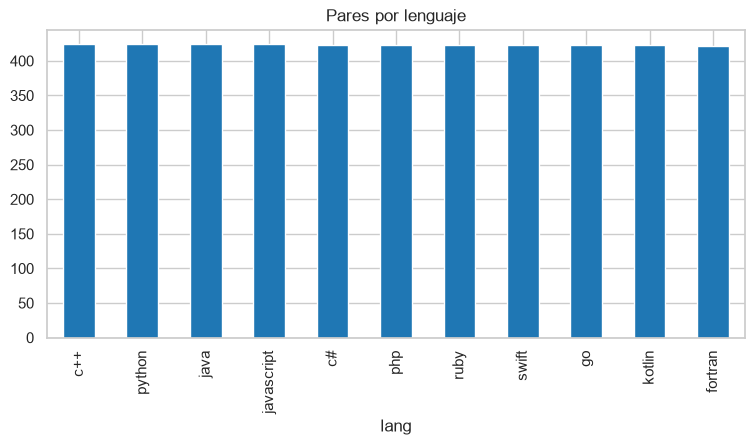

Descripciones de vulnerabilidad únicas: 4388 de 4656


vulnerability
Cross-Site Scripting (XSS) vulnerabilities in JavaScript can allow attackers to inject malicious scripts into web pages viewed by other users.    12
Insecure deserialization of objects can lead to remote code execution.                                                                             9
Improper handling of user input can lead to SQL Injection vulnerabilities.                                                                         9
Buffer overflow vulnerability in C++ can occur when a programmer writes more data into a buffer than it can handle.                                9
The use of uninitialized variables in Fortran can lead to unexpected results or crashes.                                                           7
Kotlin's null safety feature can lead to NullPointerException if not properly handled.                                                             7
Improper validation and sanitization of user input can lead to SQL Injection vulnerabilities

Filas con system vacío: 4656


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
df["lang"].value_counts().plot.bar(ax=ax); ax.set_title("Pares por lenguaje")
save_fig(fig, ctx, "pares_por_lenguaje"); plt.show()

print("Descripciones de vulnerabilidad únicas:", df["vulnerability"].nunique(), "de", len(df))
display(df["vulnerability"].value_counts().head(15))
print("Filas con system vacío:", (df["system"].fillna("").str.strip() == "").sum())

## 4. Largo de `chosen` vs `rejected`

,question,chosen,rejected
count,4656.000000,4656.000000,4656.000000
mean,286.679553,534.105670,387.271692
std,158.508425,413.400144,420.071898
min,50.000000,55.000000,63.000000
25%,159.000000,299.000000,207.000000
50%,249.000000,461.000000,305.000000
75%,390.000000,662.250000,470.000000
max,1007.000000,8925.000000,8003.000000


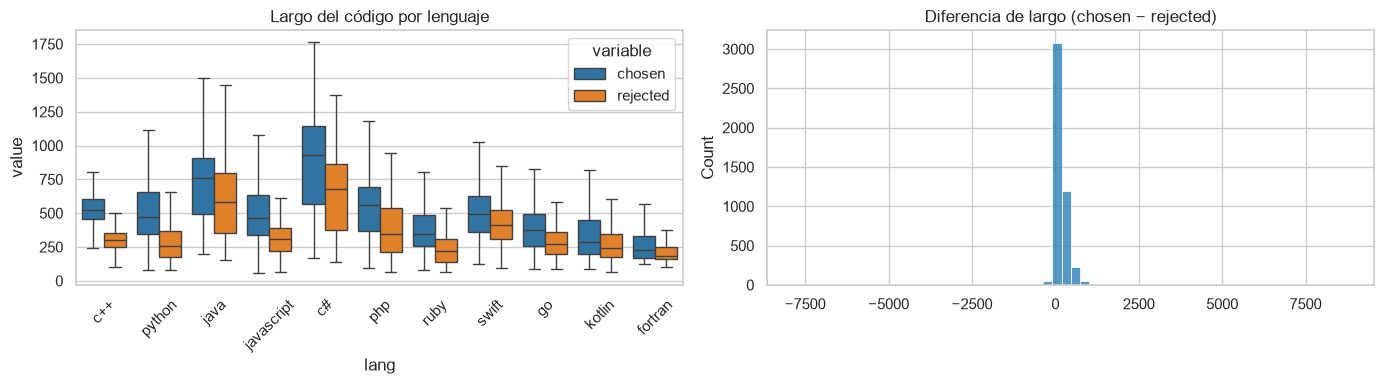

% de pares donde chosen es más largo: 88.3%


In [5]:
L = text_lengths(df, ["question", "chosen", "rejected"])
L["lang"] = df["lang"]
display(L.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
L.melt(id_vars="lang", value_vars=["chosen", "rejected"]).pipe(
    lambda d: sns.boxplot(data=d, x="lang", y="value", hue="variable", ax=axes[0], showfliers=False))
axes[0].set_title("Largo del código por lenguaje"); axes[0].tick_params(axis="x", rotation=45)
sns.histplot(L["chosen"] - L["rejected"], bins=60, ax=axes[1])
axes[1].set_title("Diferencia de largo (chosen − rejected)")
plt.tight_layout(); save_fig(fig, ctx, "largo_chosen_rejected"); plt.show()
print(f"% de pares donde chosen es más largo: {(L.chosen > L.rejected).mean():.1%}")

## 5. Duplicados

In [6]:
display(duplicates_report(df, {"question": ["question"], "chosen": ["chosen"],
                               "rejected": ["rejected"], "chosen == rejected": ["chosen", "rejected"]}))
print("Pares con chosen idéntico a rejected:", (df["chosen"] == df["rejected"]).sum())

,duplicados,%
criterio,,
question,500,10.74
chosen,195,4.19
rejected,637,13.68
chosen == rejected,159,3.41


Pares con chosen idéntico a rejected: 26


## 6. Ejemplos

In [7]:
show_examples(df, n=2, cols=["lang", "vulnerability", "question", "chosen", "rejected"], max_chars=700)

fila 533
--- lang ---
php
--- vulnerability ---
PHP's `extract()` function may allow arbitrary code execution through the `$this` variable, which can lead to unintended code execution.
--- question ---
Write a php code that creates a class named MyClass with a private variable and a public method to get the value of the variable. Create an object of MyClass with a user input that can be exploited by the extract function to execute system commands. The exploit is achieved by passing a string containing a command to remove all files in the root directory.
--- chosen ---
```php
<?php
class MyClass {
    private $variable;

    public function __construct($input) {
        $this->setVariable($input);
    }

    public function setVariable($input) {
        // Sanitize and validate the input before setting it
        $input = filter_var($input, FILTER_SANITIZE_STRING);
        if ($this->isValidCommand($input)) {
            $this->variable = $input;
        } else {
            throw new E

### Caso de Estudio: Fila 533 — Ejecución de Comandos en PHP

* **Lenguaje:** PHP
* **Vulnerabilidad:** Uso inseguro de la función `extract()`.

#### ¿Qué pidió el usuario (`question`)?
Crear una clase en PHP que reciba datos ingresados por un usuario, demostrando cómo la función `extract()` puede ser manipulada para ejecutar comandos destructivos del sistema (en este caso, la orden de borrar todos los archivos: `rm -rf /`).

#### ❌ Código Vulnerable (`rejected`):
Usa la función `extract($userInput)` directamente con los datos del usuario sin ninguna revisión.
* **El peligro:** La función `extract()` toma los datos externos y los convierte en variables reales dentro de la memoria. Si un atacante envía la clave `'system("rm -rf /")'`, el servidor web ejecuta esa orden y borra el sistema operativo completo.

#### ✅ Código Seguro (`chosen`):
No utiliza `extract()`.
* **La solución:** 
  1. Asigna los datos directamente al objeto sin alterar las variables globales.
  2. Limpia y valida el texto con `filter_var($input, FILTER_SANITIZE_STRING)`.
  3. Comprueba que el comando sea válido (`isValidCommand`) y maneja cualquier intento inválido con una excepción de seguridad (`try / catch`).


In [8]:
# Muestra el ejemplo de Inyección SQL (Fila 5) con formato limpio
ejemplo_sql = df.iloc[5]

display(Markdown(f"""
### 📌 Caso Más Común: {ejemplo_sql['vulnerability']}
* **Lenguaje:** `{ejemplo_sql['lang']}`

#### ❓ Tarea del usuario (`question`):
{ejemplo_sql['question']}

---
#### ❌ Código Vulnerable (`rejected` - Lo que la IA NO debe dar):
{ejemplo_sql['rejected']}

> **Fallo:** Concatena directamente las variables del usuario en la consulta SQL (`WHERE username='$user'`). Un atacante puede saltarse la contraseña escribiendo `' OR 1=1 --`.

---
#### ✅ Código Seguro (`chosen` - Lo que la IA SÍ debe dar):
{ejemplo_sql['chosen']}

> **Corrección:** Utiliza **consultas preparadas / parametrizadas** (`prepare()` y `bind_param()`), impidiendo físicamente que la entrada del usuario modifique la consulta SQL.
"""))



### 📌 Caso Más Común: Improper Input Validation and Sanitization in PHP can lead to SQL Injection
* **Lenguaje:** `php`

#### ❓ Tarea del usuario (`question`):
Write a php code that connects to a MySQL database and fetches data from a table named 'users' where the username and password match those provided in the URL parameters.

---
#### ❌ Código Vulnerable (`rejected` - Lo que la IA NO debe dar):
```php
<?php
$db = new PDO('mysql:host=localhost;dbname=test', $user, $pass);

$username = $_GET['username'];
$password = $_GET['password'];

$sql = "SELECT * FROM users WHERE username = '$username' AND password = '$password'";

foreach ($db->query($sql) as $row) {
    print_r($row);
}
?>
```

> **Fallo:** Concatena directamente las variables del usuario en la consulta SQL (`WHERE username='$user'`). Un atacante puede saltarse la contraseña escribiendo `' OR 1=1 --`.

---
#### ✅ Código Seguro (`chosen` - Lo que la IA SÍ debe dar):
```php
<?php
$db = new PDO('mysql:host=localhost;dbname=test', $user, $pass);

$username = $_GET['username'];
$password = $_GET['password'];

// Prepare our SQL, preparing the SQL statement removes the risk of SQL injection.
$stmt = $db->prepare("SELECT * FROM users WHERE username = :username AND password = :password");

// Bind the value to the parameter
$stmt->bindParam(':username', $username);
$stmt->bindParam(':password', $password);

// Execute the statement
$stmt->execute();

// Fetch all of the remaining rows in the result set
print_r($stmt->fetchAll());
?>
```

> **Corrección:** Utiliza **consultas preparadas / parametrizadas** (`prepare()` y `bind_param()`), impidiendo físicamente que la entrada del usuario modifique la consulta SQL.


In [10]:
# Muestra el ejemplo de Ataque de Tiempo / Timing Attack (Fila 111) con formato limpio
ejemplo_timing = df.iloc[111]

display(Markdown(f"""
### 📌 Caso Moderno / Avanzado: {ejemplo_timing['vulnerability']}
* **Lenguaje:** `{ejemplo_timing['lang']}`

#### ❓ Tarea del usuario (`question`):
{ejemplo_timing['question']}

---
#### ❌ Código Vulnerable (`rejected` - Lo que la IA NO debe dar):
{ejemplo_timing['rejected']}

> **Fallo:** Usa el operador `==`, el cual se detiene en la primera letra incorrecta. Un atacante puede medir los microsegundos de respuesta para adivinar contraseñas o tokens carácter por carácter (ataque de canal lateral).

---
#### ✅ Código Seguro (`chosen` - Lo que la IA SÍ debe dar):
{ejemplo_timing['chosen']}

> **Corrección:** Utiliza `hmac.compare_digest()`, que compara en **tiempo constante** (recorre siempre la cadena completa hasta el final), impidiendo que se deduzca información a través de diferencias de tiempo.
"""))



### 📌 Caso Moderno / Avanzado: Python code can face a timing attack vulnerability due to its use of '==' operator for string comparison.
* **Lenguaje:** `python`

#### ❓ Tarea del usuario (`question`):
Write a python code that asks for a password from the user and checks if it matches a predefined password. If the password is correct, print 'Access granted.' and if not, print 'Access denied.' Also, calculate and print the time taken to enter the password.

---
#### ❌ Código Vulnerable (`rejected` - Lo que la IA NO debe dar):
```python
import time

def check_password(input_password):
    actual_password = "secret"
    if input_password == actual_password:
        return True
    else:妆
        return False

def main():
    input_password = input("Enter your password: ")
    start = time.time()
    if check_password(input_password):
        print("Access granted.")
    else:
        print("Access denied.")
    end = time.time()
    print("Time taken: ", end - start)

if __name__ == "__main__":
    main()
```

> **Fallo:** Usa el operador `==`, el cual se detiene en la primera letra incorrecta. Un atacante puede medir los microsegundos de respuesta para adivinar contraseñas o tokens carácter por carácter (ataque de canal lateral).

---
#### ✅ Código Seguro (`chosen` - Lo que la IA SÍ debe dar):
```python
import time
import hmac
from hashlib import sha256

# Hashed version of the password
actual_password = "5ebe2294ecd0e0f08eab7690d2a6ee69"  # Hashed form of "secret"

def check_password(input_password):
    hashed_input_password = sha256(input_password.encode()).hexdigest()
    if hmac.compare_digest(hashed_input_password, actual_password):
        return True
    else:
        return False

def main():
    input_password = input("Enter your password: ")
    start = time.time()
    if check_password(input_password):
        print("Access granted.")
    else:
        print("Access denied.")
    end = time.time()
    print("Time taken: ", end - start)

if __name__ == "__main__":
    main()
```

> **Corrección:** Utiliza `hmac.compare_digest()`, que compara en **tiempo constante** (recorre siempre la cadena completa hasta el final), impidiendo que se deduzca información a través de diferencias de tiempo.
